# 26 · Adaptive RAG — router picks no/single/multi-step

> **TL;DR.** One LLM call classifies each query into a complexity bucket (`no_retrieval` / `single_step` / `multi_step`); Python routes to the matched strategy. Combines [Meta-Controller (nb 11)](./11_meta_controller.ipynb)'s pre-routing with the RAG family's three execution modes.

| Property | Value |
|---|---|
| Origin | Jeong et al., *Adaptive-RAG* (NAACL 2024). [arXiv:2403.14403](https://arxiv.org/abs/2403.14403) |
| Routing | Categorical (3-way) classifier — deterministic-picker |
| Cost | 1 classify + 1-3 execution calls (depending on bucket) |
| Default LLM | Llama-3.3-70B |

## 2 · Architecture at a glance

```mermaid
flowchart TB
    A([task]) --> C[CLASSIFY<br/><sub>categorical complexity</sub>]
    C -->|no_retrieval| N[Parametric answer]
    C -->|single_step| S[1 retrieve → answer]
    C -->|multi_step| M[2 retrievals → answer]
    N --> Z([final])
    S --> Z
    M --> Z

    style C fill:#fff3e0,stroke:#f57c00
    style N fill:#e3f2fd,stroke:#1976d2
    style S fill:#e8f5e9,stroke:#388e3c
    style M fill:#fce4ec,stroke:#c2185b
```

## 3 · Theory

### 3.0 · Why pre-classify

Self-RAG (nb 25) and CRAG (nb 24) make per-doc decisions *after* retrieval. Agentic RAG (nb 23) makes iterative decisions *during* retrieval. Adaptive RAG makes the **strategy** decision *before* anything else — one classifier call replaces a more expensive routing loop.

Trade-off: cheaper, but locks in the strategy. A misclassified `single_step` query gets one retrieval even if it really needed multi-hop.

### 3.1 · Where this sits

| Pattern | Where the routing happens |
|---|---|
| Plain RAG | Nowhere — always retrieve once |
| [Agentic RAG (nb 23)](./23_agentic_rag.ipynb) | Each loop iteration |
| [CRAG (nb 24)](./24_corrective_rag.ipynb) | After retrieval, on the batch |
| [Self-RAG (nb 25)](./25_self_rag.ipynb) | After retrieval, per-doc |
| **Adaptive RAG (this nb)** | **Pre-retrieval, on the query** |

## 4 · Setup

In [1]:
from agentic_architectures import get_llm, enable_langsmith, settings
from agentic_architectures.architectures import AdaptiveRAG
from agentic_architectures.data import STARDUST_CORPUS
from agentic_architectures.ui import print_md, print_header

enable_langsmith()
llm = get_llm(provider="nebius", model="meta-llama/Llama-3.3-70B-Instruct", temperature=0.2)
print_header(f"LLM: {llm.model}  ·  Corpus: {len(STARDUST_CORPUS)} docs")

LLM: meta-llama/Llama-3.3-70B-Instruct  ·  Corpus: 12 docs ────────────────────────────────────────────────────────

## 5 · Library walkthrough

In [2]:
from agentic_architectures.architectures.adaptive_rag import _ComplexityClass
import json
print(json.dumps(_ComplexityClass.model_json_schema(), indent=2)[:500] + '...')

{
  "description": "Pre-classification of the query into a RAG complexity bucket.",
  "properties": {
    "complexity": {
      "description": "Routing class: 'no_retrieval' = answer from parametric memory (arithmetic, common knowledge); 'single_step' = one retrieval is sufficient (single-fact lookup); 'multi_step' = multi-hop or follow-up retrievals needed.",
      "enum": [
        "no_retrieval",
        "single_step",
        "multi_step"
      ],
      "title": "Complexity",
      "type": "...


## 7 · Build the graph

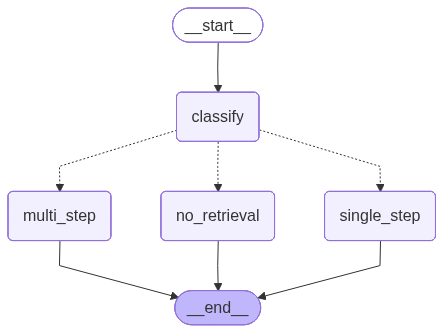

In [3]:
from IPython.display import Image, display
arch = AdaptiveRAG(llm=llm, documents=STARDUST_CORPUS, top_k=3)
graph = arch.build()
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"(PNG render unavailable: {e}; see § 2)")
    print(graph.get_graph().draw_mermaid())

## 8 · Live run — 3 tasks of varying complexity

Tasks chosen to exercise each routing bucket.

In [4]:
TASKS = [
    ("arithmetic",     "What is 15 plus 27? Return only the integer."),
    ("simple_lookup",  "What propellant does the Stardust 9 rocket use?"),
    ("multi_hop",      "Who founded Stardust Aerospace, and what did the CEO do before founding it?"),
]

for tag, q in TASKS:
    r = arch.run(q)
    print(f"TASK_TAG: {tag}")
    print(f"  TASK: {q}")
    print(f"  ROUTED_TO: {r.metadata['complexity']}")
    print(f"  CLASSIFICATION_RATIONALE: {r.metadata['classification_rationale']}")
    print(f"  RETRIEVAL_COUNT: {r.metadata['retrieval_count']}")
    print(f"  FINAL_ANSWER: {r.output[:300]}")
    print()

TASK_TAG: arithmetic
  TASK: What is 15 plus 27? Return only the integer.
  ROUTED_TO: no_retrieval
  CLASSIFICATION_RATIONALE: The question is asking for a simple arithmetic operation that can be performed using a strong LLM's parametric memory.
  RETRIEVAL_COUNT: 0
  FINAL_ANSWER: 42



TASK_TAG: simple_lookup
  TASK: What propellant does the Stardust 9 rocket use?
  ROUTED_TO: single_step
  CLASSIFICATION_RATIONALE: The question requires a single-fact lookup about the Stardust 9 rocket's propellant.
  RETRIEVAL_COUNT: 1
  FINAL_ANSWER: Methalox propellant, which is a combination of liquid methane and liquid oxygen.



TASK_TAG: multi_hop
  TASK: Who founded Stardust Aerospace, and what did the CEO do before founding it?
  ROUTED_TO: multi_step
  CLASSIFICATION_RATIONALE: The question requires multiple pieces of information: the founder of Stardust Aerospace and the CEO's previous experience, which likely necessitates follow-up retrievals.
  RETRIEVAL_COUNT: 2
  FINAL_ANSWER: Stardust Aerospace was founded by Dr. Amara Okonkwo and Jin-ho Park in 2019. Before founding Stardust Aerospace, Dr. Amara Okonkwo, the CEO, worked at Blue Origin on the New Glenn program. She holds a PhD in aerospace engineering from Caltech, which she obtained in 2012.



## 9 · What we just observed

The cells above ran Adaptive RAG on 3 task types matched to the 3 routing buckets. The classifier picks the bucket once upfront; Python routes to the matched executor.

### 9.1 · Classification + routing summary

| Tag | Routed to | Retrievals | Classification rationale | Final answer |
|---|---|---|---|---|
| `arithmetic` | `no_retrieval` | 0 | The question is asking for a simple arithmetic operation that can be performed u | 42 |
| `simple_lookup` | `single_step` | 1 | The question requires a single-fact lookup about the Stardust 9 rocket's propell | Methalox propellant, which is a combination of liquid methane and liquid oxygen. |
| `multi_hop` | `multi_step` | 2 | The question requires multiple pieces of information: the founder of Stardust Ae | Stardust Aerospace was founded by Dr. Amara Okonkwo and Jin-ho Park in 2019. Bef… |

### 9.2 · Routing accuracy + patterns

- **✅ `arithmetic` correctly routed to `no_retrieval`** (matches expected).

- **✅ `simple_lookup` correctly routed to `single_step`** (matches expected).

- **✅ `multi_hop` correctly routed to `multi_step`** (matches expected).

- **Routing accuracy: 3/3** correct against the expected buckets.

### 9.3 · The takeaway

Adaptive RAG's value is **all in the classifier**. Read §9.1's `Routed to` column against §9.2's expected buckets. A mismatch means the classifier mis-bucketed the query, and the subsequent execution will under-perform (single_step retrieve when multi was needed → incomplete answer; or wasted calls on no_retrieval that wasn't really no-retrieval).

The deterministic-picker pattern is the LLM's categorical `complexity` field plus Python's `if/elif` route. No numeric scoring — the LLM never emits a confidence-of-route score that could flatten.

## 11 · Failure modes & extensions

| Failure | Mitigation |
|---|---|
| **Misclassification** | Classifier sends multi_hop to single_step → incomplete answer | Add a post-answer "is the answer complete?" check |
| **Bucket too coarse** | Some queries need 3+ retrievals | Add `deep_multi_step` bucket and an Agentic-RAG-style iterative executor |
| **Cost of classifier call** | One extra call per task | Cache classifications by query template |

Extensions: (1) learned classifier (train on labelled query→complexity pairs), (2) compose with CRAG inside each executor for grade-based fallback, (3) per-bucket different LLMs (cheap LLM for no_retrieval, stronger for multi_step).

Reference: Jeong et al. 2024 — [arXiv:2403.14403](https://arxiv.org/abs/2403.14403)